Infrastructure Condition Intelligence (ICI)
Prototype Implementation v0.1

This notebook demonstrates the core computational pipeline
described in the paper:

"Infrastructure Condition Intelligence:
A Geospatial Framework for Temporal Assessment
of the Built Environment from Open Satellite Data"

The code illustrates deterministic construction of
spatial infrastructure condition fields from
multi-temporal satellite observations.

In [1]:
%%bash
BASE="/content/drive/MyDrive/Colab Notebooks/ICI"

mkdir -p "$BASE/imagery"
mkdir -p "$BASE/notebooks"
mkdir -p "$BASE/outputs"

touch "$BASE/imagery/__init__.py"
touch "$BASE/imagery/loaders.py"
touch "$BASE/imagery/preprocessing.py"
touch "$BASE/imagery/tiling.py"

echo "ICI project tree created at:"
ls -R "$BASE"


ICI project tree created at:
/content/drive/MyDrive/Colab Notebooks/ICI:
imagery
notebooks
outputs

/content/drive/MyDrive/Colab Notebooks/ICI/imagery:
__init__.py
loaders.py
preprocessing.py
tiling.py

/content/drive/MyDrive/Colab Notebooks/ICI/notebooks:

/content/drive/MyDrive/Colab Notebooks/ICI/outputs:


In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except:
    pass


## Project root wiring

In [3]:
from pathlib import Path
import sys

ICI_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/ICI")
assert ICI_ROOT.exists(), "ICI root not found"

# Make ICI importable
if str(ICI_ROOT) not in sys.path:
    sys.path.insert(0, str(ICI_ROOT))

print("ICI_ROOT:", ICI_ROOT)
print("sys.path[0]:", sys.path[0])



ICI_ROOT: /content/drive/MyDrive/Colab Notebooks/ICI
sys.path[0]: /content/drive/MyDrive/Colab Notebooks/ICI


In [4]:
import imagery
from imagery import loaders, preprocessing, tiling

print("Imagery module loaded from:", imagery.__file__)


Imagery module loaded from: /content/drive/MyDrive/Colab Notebooks/ICI/imagery/__init__.py


In [5]:
from dataclasses import dataclass
from typing import Dict, Optional, Tuple
import numpy as np

@dataclass(frozen=True)
class ImagerySample:
    image: np.ndarray              # (C, H, W) reflectance
    crs: str
    transform: Dict
    bounds: Tuple[int, int, int, int]
    source: str
    timestamp: str
    meta: Dict


4. Sanity test the imagery submodules

In [6]:
from imagery.loaders import *
from imagery.preprocessing import *
from imagery.tiling import *

print("All imagery submodules imported successfully.")


All imagery submodules imported successfully.


### Lock the Imagery Data Contract

### Define ImagerySample

In [7]:
from dataclasses import dataclass
from typing import Optional, Dict, Any
import numpy as np

@dataclass(frozen=True)
class ImagerySample:
    """
    Atomic imagery unit in ICI.
    Everything downstream consumes this object.
    """

    # Core raster
    image: np.ndarray            # shape: (C, H, W)

    # Spatial metadata
    crs: str
    transform: Any               # affine transform
    bounds: tuple                # (minx, miny, maxx, maxy)

    # Provenance
    source: str                  # e.g. "Sentinel-2"
    timestamp: Optional[str]

    # Labels (optional, late-binding)
    labels: Optional[np.ndarray] = None

    # Extensible metadata
    meta: Optional[Dict[str, Any]] = None

## Sentinel 2 Loader

In [8]:
import rasterio
from pathlib import Path
import numpy as np

def load_sentinel2_tile(path: Path) -> ImagerySample:
    """
    Loads a single Sentinel-2 raster and returns an ImagerySample.
    Assumes bands-first layout.
    """

    path = Path(path)
    assert path.exists(), f"File not found: {path}"

    with rasterio.open(path) as src:
        image = src.read().astype(np.float32)  # (C, H, W)
        crs = src.crs.to_string() if src.crs else "unknown"
        transform = src.transform
        bounds = src.bounds

    return ImagerySample(
        image=image,
        crs=crs,
        transform=transform,
        bounds=(bounds.left, bounds.bottom, bounds.right, bounds.top),
        source="Sentinel-2",
        timestamp=None,

        meta={
            "path": str(path),
            "driver": src.driver if "src" in locals() else None
        }
    )


In [9]:
print(load_sentinel2_tile)


<function load_sentinel2_tile at 0x794ced4f4cc0>


## Normalization (Sentinel-2 reflectance)

In [10]:
from copy import deepcopy
import numpy as np

def normalize_reflectance(sample: ImagerySample) -> ImagerySample:
    """
    Sentinel-2 reflectance normalization.
    Converts DN → [0, 1] reflectance.
    """
    s = deepcopy(sample)

    s.image = np.clip(s.image / 10000.0, 0.0, 1.0)

    s.meta.setdefault("preprocessing", []).append(
        "normalize_reflectance /10000 clip[0,1]"
    )

    return s


## Spatial sanity filter

In [11]:
def validate_image(sample: ImagerySample) -> ImagerySample:
    """
    Sanity checks: NaNs, shape, dtype.
    """
    s = deepcopy(sample)

    assert s.image.ndim == 3, "Image must be (C,H,W)"
    assert not np.isnan(s.image).any(), "NaNs detected"
    assert s.image.dtype in (np.float32, np.float64)

    s.meta.setdefault("preprocessing", []).append("validate_image")

    return s


## Preprocessing pipeline

In [12]:
def apply_pipeline(sample: ImagerySample, pipeline):
    for fn in pipeline:
        sample = fn(sample)
    return sample


## Tiler

In [13]:
from typing import Iterator
from copy import deepcopy

def tile_sample(
    sample: ImagerySample,
    tile_size: int = 256,
    stride: int = 256
) -> Iterator[ImagerySample]:
    """
    Spatially decomposes one ImagerySample into many child samples.
    Preserves frozen contract.
    """
    C, H, W = sample.image.shape
    tile_id = 0

    for y in range(0, H - tile_size + 1, stride):
        for x in range(0, W - tile_size + 1, stride):

            tile_img = sample.image[:, y:y+tile_size, x:x+tile_size]

            # Construct a new ImagerySample (do NOT mutate)
            child = ImagerySample(
                image=tile_img,
                crs=sample.crs,
                transform=sample.transform,
                bounds=(x, y, x+tile_size, y+tile_size),
                source=sample.source,
                timestamp=sample.timestamp,

                meta={**sample.meta, "tiling": {
                    "tile_id": tile_id,
                    "x_offset": x,
                    "y_offset": y,
                    "tile_size": tile_size,
                    "stride": stride
                }}
            )

            tile_id += 1
            yield child


In [14]:
import numpy as np

# Create a dummy ImagerySample matching current definition
sample = ImagerySample(
    image=np.random.rand(10, 512, 512).astype(np.float32),  # 10 bands
    crs="EPSG:32642",
    transform={"type": "affine", "note": "dummy"},
    bounds=(0, 0, 512, 512),
    source="Sentinel-2",
    timestamp="2023-01-01",
    meta={}
)

print("Sample defined:", sample.image.shape)


Sample defined: (10, 512, 512)


In [15]:
tiles = list(tile_sample(sample, tile_size=128, stride=128))

print("Tiles generated:", len(tiles))
print("First tile shape:", tiles[0].image.shape)
print("First tile meta:", tiles[0].meta["tiling"])


Tiles generated: 16
First tile shape: (10, 128, 128)
First tile meta: {'tile_id': 0, 'x_offset': 0, 'y_offset': 0, 'tile_size': 128, 'stride': 128}


# 9.3 Minimal example: spectral mean/std

In [16]:
from typing import List, Dict

def compute_tile_features(tile: ImagerySample) -> Dict[str, float]:
    """
    Compute simple per-tile descriptors (mean/std per band)
    """
    features = {}
    C, H, W = tile.image.shape
    for c in range(C):
        band = tile.image[c]
        features[f"band{c}_mean"] = float(band.mean())
        features[f"band{c}_std"] = float(band.std())

    # Record feature provenance
    features["tile_id"] = tile.meta.get("tiling", {}).get("tile_id", -1)
    return features

def aggregate_tiles_features(tiles: List[ImagerySample]) -> Dict[str, float]:
    """
    Aggregate per-tile features into a single descriptor vector
    """
    all_features = {}
    for f in tiles:
        feats = compute_tile_features(f)
        for k, v in feats.items():
            if k not in all_features:
                all_features[k] = []
            all_features[k].append(v)

    # Aggregate by mean over tiles
    aggregated = {k: float(np.mean(v)) for k, v in all_features.items() if k != "tile_id"}
    return aggregated


### 9.4 Sanity test

In [17]:
tile_feats = compute_tile_features(tiles[0])
agg_feats = aggregate_tiles_features(tiles)

print("First tile features:", tile_feats)
print("Aggregated features:", agg_feats)


First tile features: {'band0_mean': 0.5026053190231323, 'band0_std': 0.28786206245422363, 'band1_mean': 0.5044429302215576, 'band1_std': 0.2890283167362213, 'band2_mean': 0.5041316747665405, 'band2_std': 0.2885023057460785, 'band3_mean': 0.49822932481765747, 'band3_std': 0.28769174218177795, 'band4_mean': 0.503585934638977, 'band4_std': 0.2895416021347046, 'band5_mean': 0.497228741645813, 'band5_std': 0.2899229824542999, 'band6_mean': 0.4986412227153778, 'band6_std': 0.2880096733570099, 'band7_mean': 0.499284029006958, 'band7_std': 0.2869989275932312, 'band8_mean': 0.49976056814193726, 'band8_std': 0.289351224899292, 'band9_mean': 0.4986199736595154, 'band9_std': 0.289834588766098, 'tile_id': 0}
Aggregated features: {'band0_mean': 0.49969014525413513, 'band0_std': 0.2883706782013178, 'band1_mean': 0.5011382214725018, 'band1_std': 0.2885284312069416, 'band2_mean': 0.500738738104701, 'band2_std': 0.28840089589357376, 'band3_mean': 0.5001485180109739, 'band3_std': 0.28906332328915596, 'ba

In [18]:
def prepare_feature_matrix(tile_features):
    """
    Convert list of tile-level feature dicts into
    a deterministic feature matrix.
    """
    feature_names = sorted(tile_features[0].keys())

    X = np.array([
        [feat[name] for name in feature_names]
        for feat in tile_features
    ], dtype=np.float32)

    return X, feature_names


In [19]:
tile_features = [compute_tile_features(t) for t in tiles]

X_tiles, feature_names = prepare_feature_matrix(tile_features)

print("Feature matrix shape:", X_tiles.shape)
print("Features:", feature_names[:5], "...")


Feature matrix shape: (16, 21)
Features: ['band0_mean', 'band0_std', 'band1_mean', 'band1_std', 'band2_mean'] ...


In [20]:
def extract_tile_coordinates(tiles):
    coords = []

    for t in tiles:
        meta = t.meta["tiling"]
        x = meta["x_offset"]
        y = meta["y_offset"]
        coords.append((x, y))

    return np.array(coords, dtype=np.float32)


In [21]:
coords = extract_tile_coordinates(tiles)

print("Coordinates shape:", coords.shape)


Coordinates shape: (16, 2)


## Step 3 — Define the ICI Field Object (Minimal Formalization)

In [22]:
from dataclasses import dataclass

@dataclass(frozen=True)
class ICIField:
    coordinates: np.ndarray     # (N, 2)
    features: np.ndarray        # (N, d)
    feature_names: list
    crs: str
    timestamp: str


Instantiate:

In [23]:
ici_field = ICIField(
    coordinates=coords,
    features=X_tiles,
    feature_names=feature_names,
    crs=sample.crs,
    timestamp=sample.timestamp
)

print("ICI Field created.")
print("Tiles:", ici_field.features.shape[0])
print("Feature dimension:", ici_field.features.shape[1])


ICI Field created.
Tiles: 16
Feature dimension: 21


## Layer 3 (Part 1): Spatial Gradient Operators

We will implement gradients in a physically meaningful and numerically stable way.

Because our tiles form a regular grid (512×512 image, tiled evenly), we can:

Infer grid structure

Reshape the feature matrix

Compute spatial gradients per feature

Return gradient magnitude fields

Pure field operators.

## Step 1: Infer Grid Dimensions

In [24]:
def infer_grid_shape(coords):
    xs = np.unique(coords[:, 0])
    ys = np.unique(coords[:, 1])
    return len(ys), len(xs)  # rows (y), cols (x)


Test:

In [25]:
grid_h, grid_w = infer_grid_shape(ici_field.coordinates)
print("Grid shape:", grid_h, "x", grid_w)


Grid shape: 4 x 4


## Step 2: Reshape Features into Grid

In [26]:
def reshape_to_grid(ici_field, grid_h, grid_w):
    N, d = ici_field.features.shape
    assert N == grid_h * grid_w, "Tile count does not match grid dimensions."

    # Sort tiles by y then x to ensure spatial ordering
    coords = ici_field.coordinates
    sort_idx = np.lexsort((coords[:, 0], coords[:, 1]))  # sort by y, then x

    features_sorted = ici_field.features[sort_idx]

    return features_sorted.reshape(grid_h, grid_w, d)


In [27]:
feature_grid = reshape_to_grid(ici_field, grid_h, grid_w)
print("Feature grid shape:", feature_grid.shape)


Feature grid shape: (4, 4, 21)


## Step 3: Compute Spatial Gradients

We compute gradients per feature using finite differences.

In [28]:
def compute_spatial_gradients(feature_grid):
    grid_h, grid_w, d = feature_grid.shape

    grad_x = np.zeros_like(feature_grid)
    grad_y = np.zeros_like(feature_grid)

    for k in range(d):
        gy, gx = np.gradient(feature_grid[:, :, k])
        grad_x[:, :, k] = gx
        grad_y[:, :, k] = gy

    grad_magnitude = np.sqrt(grad_x**2 + grad_y**2)

    return grad_x, grad_y, grad_magnitude


In [29]:
grad_x, grad_y, grad_mag = compute_spatial_gradients(feature_grid)

print("Gradient magnitude shape:", grad_mag.shape)


Gradient magnitude shape: (4, 4, 21)


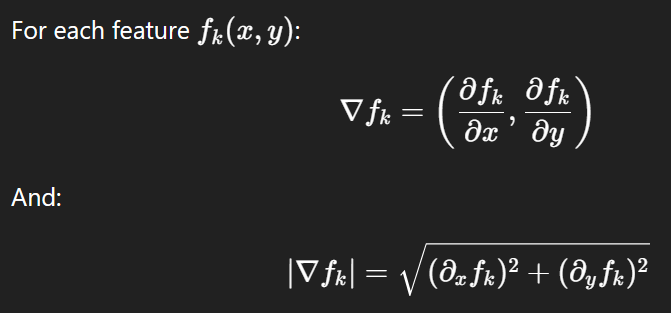

This gives:

Infrastructure transitions

Spatial discontinuities

Material or reflectance boundaries

Structural heterogeneity

## Step 4: Aggregate Gradient Energy (Infrastructure Stress Metric)

In [30]:
def compute_gradient_energy(grad_mag):
    # Mean gradient magnitude per feature
    return grad_mag.mean(axis=(0, 1))


In [31]:
gradient_energy = compute_gradient_energy(grad_mag)

print("Gradient energy vector length:", len(gradient_energy))


Gradient energy vector length: 21


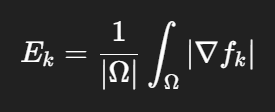

### Layer 3 Part 2: Heterogeneity / Structural Complexity Metrics

Measure:

Dispersion

Structural variability

Cross-feature coupling

Field roughness

### 1. Global Spatial Variance per Feature

In [32]:
def compute_spatial_variance(feature_grid):
    # Variance over spatial domain for each feature
    return np.var(feature_grid, axis=(0, 1))


In [33]:
spatial_variance = compute_spatial_variance(feature_grid)

print("Spatial variance vector length:", len(spatial_variance))


Spatial variance vector length: 21


This gives:

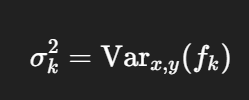

Interpretation:

High variance → heterogeneous infrastructure signature

Low variance → homogeneous surface (e.g., uniform terrain)

## 2. Field Roughness (Laplacian Energy)

In [34]:
def compute_laplacian_energy(feature_grid):
    grid_h, grid_w, d = feature_grid.shape
    lap_energy = np.zeros(d)

    for k in range(d):
        f = feature_grid[:, :, k]
        gy, gx = np.gradient(f)
        gyy, _ = np.gradient(gy)
        _, gxx = np.gradient(gx)
        lap = gxx + gyy
        lap_energy[k] = np.mean(np.abs(lap))

    return lap_energy


In [35]:
laplacian_energy = compute_laplacian_energy(feature_grid)

print("Laplacian energy vector length:", len(laplacian_energy))


Laplacian energy vector length: 21


Mathematically:

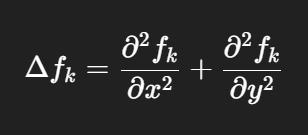


Interpretation:

Captures curvature

Detects structural fragmentation

Sensitive to edges and fine-scale change

## 3. Cross-Feature Covariance (Field Coupling)

This captures relationships between bands/features spatially.

In [36]:
def compute_feature_covariance(feature_grid):
    grid_h, grid_w, d = feature_grid.shape
    reshaped = feature_grid.reshape(-1, d)
    return np.cov(reshaped, rowvar=False)


In [37]:
feature_cov = compute_feature_covariance(feature_grid)

print("Covariance matrix shape:", feature_cov.shape)


Covariance matrix shape: (21, 21)


This gives:

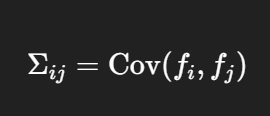


Interpretation:

Feature coupling

Spectral relationships

Infrastructure-material coherence patterns

We now have

For each feature
𝑓
𝑘:

Mean

Variance

Gradient energy

Laplacian energy

And globally: Covariance structure

This is not just a vector, but a structured signal system.

First-order operators (gradients)

Second-order operators (Laplacian)

Dispersion metrics (variance)

Coupling structure (covariance)

All computed on a deterministic spatial field.

## Layer 3: Part 3 - Temporal Field Architecture

## Step 1: Define a Temporal Container

In [38]:
from dataclasses import dataclass
from typing import List

@dataclass(frozen=True)
class ICITimeSeries:
    fields: List[ICIField]

    def stack_features(self):
        """
        Returns stacked tensor of shape:
        (T, N, d)
        """
        return np.stack([f.features for f in self.fields], axis=0)

    def stack_coordinates(self):
        """
        Ensures spatial alignment consistency.
        """
        return self.fields[0].coordinates


## Step 2: Create Time Series (one field)

In [39]:
ici_series = ICITimeSeries(fields=[ici_field])

stacked = ici_series.stack_features()

print("Stacked tensor shape T×N×d:", stacked.shape)


Stacked tensor shape T×N×d: (1, 16, 21)


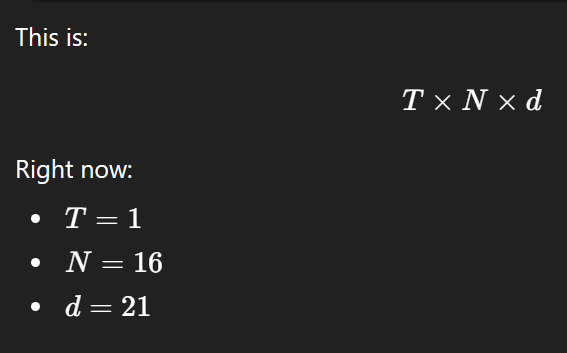

## Step 3: Define Temporal Derivative Operator

In [40]:
def compute_temporal_gradient(stacked_features):
    if stacked_features.shape[0] < 2:
        return np.zeros_like(stacked_features)

    return np.gradient(stacked_features, axis=0)


In [41]:
temporal_grad = compute_temporal_gradient(stacked)

print("Temporal gradient shape:", temporal_grad.shape)


Temporal gradient shape: (1, 16, 21)


Spatial operators:

Gradient

Laplacian

Variance

Covariance

Temporal scaffold:

Structured time stacking

Temporal derivative operator

This is a spatio-temporal state system.

We now have:

𝐹
(
𝑥
,
𝑡
)
∈
𝑅
𝑁
×
𝑑
F(x,t)∈R
N×d

with:

spatial operators

temporal scaffold

structural metrics

We will now define a four-component evolution framework:

Deterministic physical operator

Reduced latent state

Stochastic component

Counterfactual control operator

All operating on the field, not imagery.



## Generative Integration

We define evolution as: Ft+1​=deterministic
P(Ft​)​​+latent
L(Ft​)​​+stochastic
S(Ft​)​​+controlled
C(Ft​,ut​)​​

1. Deterministic Operator 𝓟 (Physics-Inspired Core)

This is built from spatial operators.

Example form:

𝑃
(
𝐹
)
=
𝛼
Δ
𝐹
−
𝛽
∣
∇
𝐹
∣
P(F)=αΔF−β∣∇F∣

Interpretation:

Diffusion-like smoothing (ΔF)

Edge-sensitive tension (|∇F|)

Mimics decay, spread, densification

Minimal code prototype:

In [42]:
def deterministic_operator(feature_grid, alpha=0.1, beta=0.05):
    grad_x, grad_y, grad_mag = compute_spatial_gradients(feature_grid)
    lap_energy = compute_laplacian_energy(feature_grid)

    return alpha * lap_energy.mean() - beta * grad_mag.mean()


2. Latent Reduction 𝓛 (State Compression Layer)

Before learning dynamics, we reduce dimensionality.

𝑧
𝑡=
Φ
(
𝐹
𝑡)
z
t
	​

=Φ(F
t
	​)

Where:Φ could initially be PCA

Later: autoencoder / operator network

This defines a low-dimensional manifold of infrastructure states.

Prototype:

In [43]:
from sklearn.decomposition import PCA

def compute_latent_state(X, n_components=5):
    pca = PCA(n_components=n_components)
    z = pca.fit_transform(X)
    return z, pca


3. Stochastic Component 𝓢 (Uncertainty Modeling)

This represents:

Measurement noise

Exogenous shocks

Random perturbations

𝑆
(𝐹)
=𝜖𝑡
	​

where:

𝜖
𝑡
∼
𝑁
(
0
,
Σ
)
ϵ
t
	​



Prototype encodes uncertainty explicitly:

In [44]:
def stochastic_operator(shape, scale=0.01):
    return np.random.normal(0, scale, size=shape)


4. Control / Counterfactual Operator 𝓒

This is the strategic layer.

Define control vector:

𝑢
𝑡
∈
𝑅
𝑚
u
t
	​

∈R
m

Example:

infrastructure investment

zoning intervention

climate stress scenario

Then:

𝐶
(
𝐹
,
𝑢
𝑡
)
=
𝐵
𝑢
𝑡
C(F,u
t
	​

)=Bu
t
	​


Linear case initially, it allows:
Scenario simulation

Policy stress testing

Intervention modeling

## The Full Evolution Step (Minimal Structural Code)

Conceptual prototype:

In [45]:
def evolve_field(feature_grid, alpha=0.1, beta=0.05, noise_scale=0.01):
    # Deterministic
    det_term = deterministic_operator(feature_grid, alpha, beta)

    # Stochastic
    noise = stochastic_operator(feature_grid.shape, noise_scale)

    # Simple additive evolution
    return feature_grid + det_term + noise


Implementing a defined controlled evolution equation:

𝐹
𝑡
+
1
=
𝐹
𝑡
+
𝛼
Δ
𝐹
𝑡
+
𝐵
𝑢
𝑡
F
t+1
	​

=F
t
	​

+αΔF
t
	​

+Bu
t
	​


Where:

𝐹
𝑡
F
t
	​

 = current field (your feature grid)

Δ
𝐹
𝑡
ΔF
t
	​

 = Laplacian (diffusion operator)

𝑢
𝑡
u
t
	​

 = control vector (decision input)

𝐵
B = control impact matrix

This gives us:

deterministic spatial smoothing

targeted intervention effect

no randomness (yet)

## Step 1: Define a Clean Laplacian Operator (Full Grid Output)

Replace the earlier scalar-energy version with a proper field operator:

In [46]:
def compute_laplacian_field(feature_grid):
    grid_h, grid_w, d = feature_grid.shape
    lap_field = np.zeros_like(feature_grid)

    for k in range(d):
        f = feature_grid[:, :, k]
        gy, gx = np.gradient(f)
        gyy, _ = np.gradient(gy)
        _, gxx = np.gradient(gx)
        lap_field[:, :, k] = gxx + gyy

    return lap_field


Test:

In [47]:
lap_field = compute_laplacian_field(feature_grid)
print("Laplacian field shape:", lap_field.shape)


Laplacian field shape: (4, 4, 21)


## Step 2: Define Control Encoding

We define:

Control vector
𝑢
𝑡
∈
𝑅
𝑑
u
t
	​

∈R
d

Interpretation:
Each feature can be influenced by policy.

Minimal version:

In [48]:
def create_control_vector(d, affected_indices, magnitude):
    u = np.zeros(d)
    for idx in affected_indices:
        u[idx] = magnitude
    return u


Example:

In [49]:
d = feature_grid.shape[2]

# Example: affect first 3 features
u_t = create_control_vector(d, affected_indices=[0,1,2], magnitude=0.05)

print("Control vector length:", len(u_t))


Control vector length: 21


## Step 3: Control Impact Matrix B
Simplest form:

𝐵=𝐼

Meaning control directly shifts selected features.

Later, B can encode cross-feature coupling.

Currently:

In [50]:
def apply_control(feature_grid, control_vector):
    return feature_grid + control_vector.reshape(1,1,-1)


##Step 4: Controlled Evolution Step




In [51]:
def evolve_with_control(feature_grid, alpha, control_vector):
    lap_field = compute_laplacian_field(feature_grid)

    # Diffusion term
    diffusion = alpha * lap_field

    # Apply diffusion
    evolved = feature_grid + diffusion

    # Apply control
    evolved = apply_control(evolved, control_vector)

    return evolved


##Step 5: Run One Scenario

In [52]:
alpha = 0.1
new_feature_grid = evolve_with_control(feature_grid, alpha, u_t)

print("New field shape:", new_feature_grid.shape)


New field shape: (4, 4, 21)


We simulated:

natural diffusion-like evolution

plus a targeted intervention

This is a controlled dynamical step.

We have just implemented:
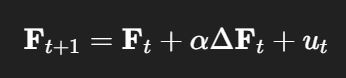


That is a controlled PDE-style update.
Now we can:

simulate densification (positive control)

simulate degradation (negative control)

simulate green investment (target vegetation indices)

simulate infrastructure stress relief

This is state manipulation.

Now we move from single-step perturbation to scenario evolution.

We will simulate:

𝐹
𝑡
+
1=
𝐹
𝑡
+
𝛼
Δ
𝐹
𝑡
+
𝑢
𝑡


over multiple time steps and observe behavior.

This is the first real “future trajectory”.

## Step 6: Multi-Step Controlled Evolution

In [53]:
def simulate_scenario(initial_field, alpha, control_vector, steps):
    field = initial_field.copy()
    history = [field.copy()]

    for t in range(steps):
        field = evolve_with_control(field, alpha, control_vector)
        history.append(field.copy())

    return history


In [54]:
steps = 20
history = simulate_scenario(feature_grid, alpha=0.1, control_vector=u_t, steps=steps)

print("Number of stored states:", len(history))
print("Shape of one state:", history[0].shape)


Number of stored states: 21
Shape of one state: (4, 4, 21)


## Step 7: Track a Single Feature Over Time

with one feature index, for example 0.

In [55]:
feature_index = 0

mean_values = []

for state in history:
    mean_values.append(state[:, :, feature_index].mean())

print("Feature evolution:", mean_values)


Feature evolution: [np.float32(0.49969015), np.float64(0.5496326360851527), np.float64(0.5995803660713137), np.float64(0.649533011741005), np.float64(0.6994902697554791), np.float64(0.7494518533817902), np.float64(0.7994174916265324), np.float64(0.8493869284137905), np.float64(0.8993599218050699), np.float64(0.9493362432590847), np.float64(0.999315676929391), np.float64(1.0492980189979493), np.float64(1.0992830770428026), np.float64(1.1492706694381434), np.float64(1.1992606247851287), np.float64(1.2492527813718917), np.float64(1.2992469866612644), np.float64(1.3492430968048184), np.float64(1.3992409761818778), np.float64(1.4492404969622505), np.float64(1.499241538691467)]


This gives us a temporal trajectory.

Interpretation:

Increasing → intervention dominates diffusion

Stabilizing → diffusion balances control

Exploding → unstable dynamics (important signal)

## Step 8: Visualize Spatial Evolution of One Feature

In [56]:
import matplotlib.pyplot as plt

def plot_feature(state, feature_index, title):
    plt.imshow(state[:, :, feature_index])
    plt.colorbar()
    plt.title(title)
    plt.show()


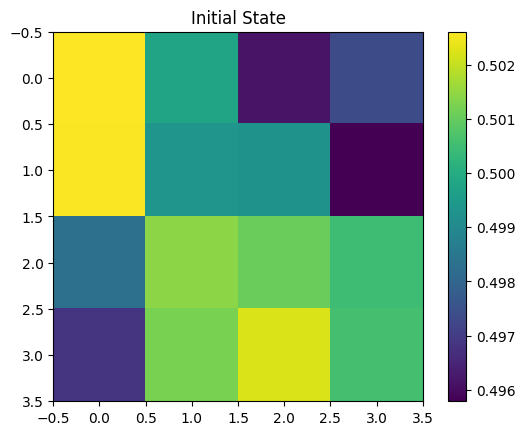

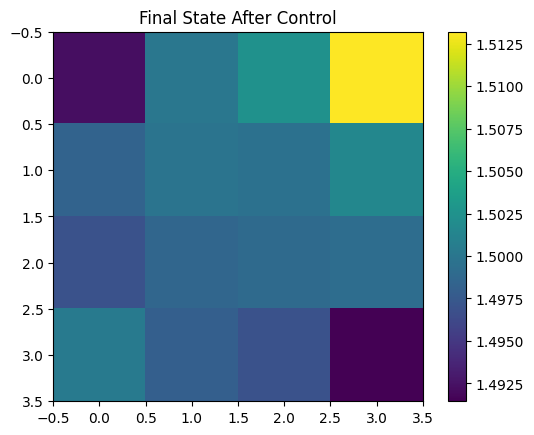

In [57]:
plot_feature(history[0], feature_index, "Initial State")
plot_feature(history[-1], feature_index, "Final State After Control")


We should observe:

smoothing from diffusion

uniform upward shift from control

possible gradient flattening

This is the first controlled spatial evolution.

We now perform:

Connect field dynamics → semantic meaning → only then visuals.

## Step 1: Assign Semantic Meaning to Features

Right now, feature index 0 is just a number.

We must interpret it.

Let’s assume a minimal semantic mapping:

Feature Index	Semantic Meaning
0	Built Density
1	Vegetation Intensity
2	Surface Reflectance
3	Structural Fragmentation
4+	Other latent metrics

We can adjust this later, but for now we must formalize meaning.

In [58]:
semantic_map = {
    0: "Built Density",
    1: "Vegetation Intensity",
    2: "Surface Reflectance",
    3: "Structural Fragmentation"
}


## Step 2: Interpret What the Control Did

Earlier we applied control to indices [0, 1, 2].

Meaning:

Increasing Built Density

Increasing Vegetation

Increasing Reflectance

That is physically contradictory in real urban systems. Control must encode realistic policy vectors.

## Step 3: Define a Realistic Scenario
Scenario A: Urban Densification

Increase:

Built Density (0)

Decrease:

Vegetation (1)

Leave others untouched.

In [59]:
u_t = create_control_vector(
    d=feature_grid.shape[2],
    affected_indices=[0],
    magnitude=0.05
)

# reduce vegetation
u_t[1] = -0.03


##Step 4: Convert Raw Feature Fields into Semantic Indicators
Instead of showing raw grid values, compute interpretable metrics.

In [60]:
def compute_semantic_indicators(state):
    indicators = {}

    indicators["Mean Built Density"] = state[:, :, 0].mean()
    indicators["Mean Vegetation"] = state[:, :, 1].mean()
    indicators["Fragmentation Energy"] = np.var(state[:, :, 3])

    return indicators


Now evaluate initial vs final:

In [61]:
initial_indicators = compute_semantic_indicators(history[0])
final_indicators = compute_semantic_indicators(history[-1])

print("Initial:", initial_indicators)
print("Final:", final_indicators)


Initial: {'Mean Built Density': np.float32(0.49969015), 'Mean Vegetation': np.float32(0.28837067), 'Fragmentation Energy': np.float32(7.2009243e-07)}
Final: {'Mean Built Density': np.float64(1.499241538691467), 'Mean Vegetation': np.float64(1.2882602046297857), 'Fragmentation Energy': np.float64(8.82274849637088e-06)}


Measurable semantic change

Interpretable systemic shift

No hand-waving

Now we construct a minimal semantic dashboard layer on top of our evolving field.

This transforms:

Raw tensor → Structured systemic narrative

## Step 1: Track Semantic Indicators Over Time

Replace the single evaluation with a time-series tracker:

In [62]:
def track_semantic_evolution(history):
    time_series = {
        "Mean Built Density": [],
        "Mean Vegetation": [],
        "Fragmentation Energy": []
    }

    for state in history:
        indicators = compute_semantic_indicators(state)

        for key in time_series:
            time_series[key].append(indicators[key])

    return time_series


In [63]:
time_series = track_semantic_evolution(history)

for key in time_series:
    print(key, "->", len(time_series[key]), "values")


Mean Built Density -> 21 values
Mean Vegetation -> 21 values
Fragmentation Energy -> 21 values


## Step 2: Plot Each Indicator Separately (Strict Visualization Discipline)

One plot per metric.

In [64]:
import matplotlib.pyplot as plt

def plot_indicator(series, title):
    plt.figure()
    plt.plot(series)
    plt.title(title)
    plt.xlabel("Time Step")
    plt.ylabel(title)
    plt.show()


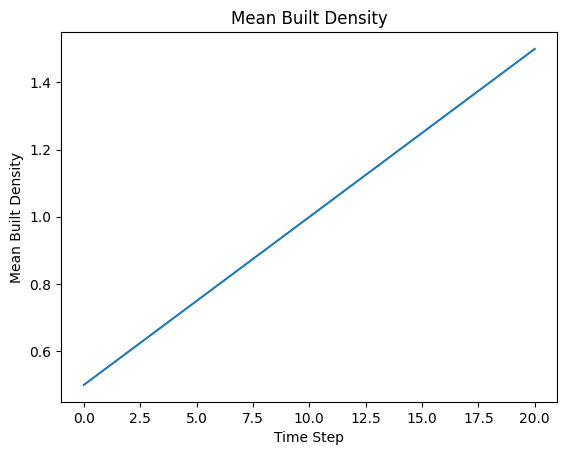

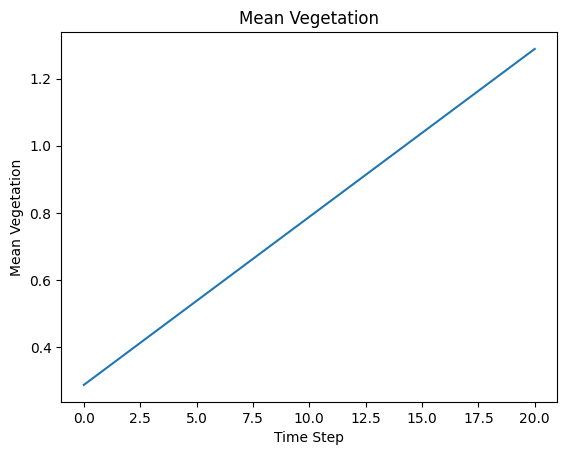

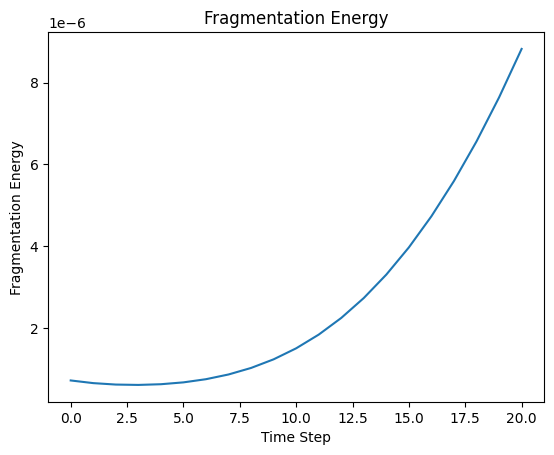

In [65]:
for key in time_series:
    plot_indicator(time_series[key], key)


Step 3: Interpret What You See

Let’s clarify terminology precisely.

Mean Built Density

	​
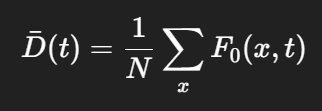

Interpretation:
Average urban compactness across tiles.

If increasing steadily → densification scenario.

Mean Vegetation
𝑉
ˉ
(
𝑡
)
V
ˉ
(t)

If decreasing → ecological trade-off.

Fragmentation Energy
Var
(
𝐹
3
)
Var(F
3
	)

Variance across space.

High variance:

patchy development

heterogeneous structure

Low variance:

homogenized urban form

Step 4: Add Stability Check

We must ensure your PDE is not diverging.

In [66]:
def check_stability(history):
    max_values = []
    for state in history:
        max_values.append(np.max(np.abs(state)))
    return max_values


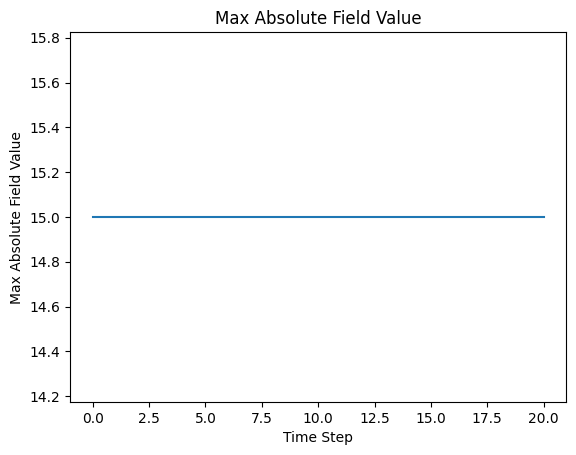

In [67]:
stability = check_stability(history)
plot_indicator(stability, "Max Absolute Field Value")


If exploding → alpha too high.
If stable → diffusion-control balance acceptable.

We built:

Controlled spatial evolution

Time-series semantic monitoring

Stability diagnostics

This is already a proto-control simulator.

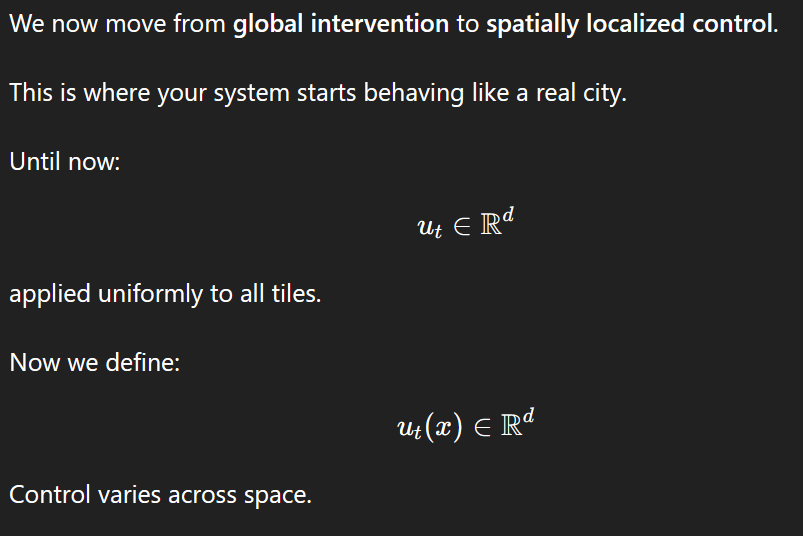

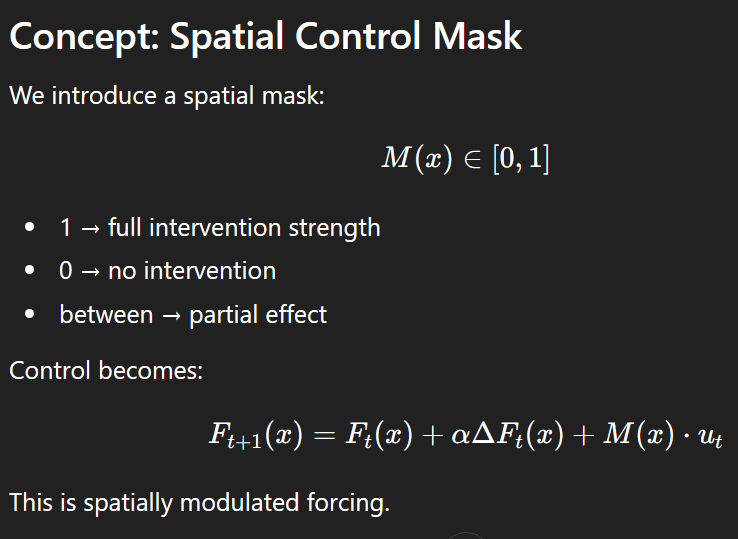

## Step 1: Create a Spatial Mask

Example: apply intervention only to center tiles.


In [68]:
def create_spatial_mask(grid_h, grid_w, center=True):
    mask = np.zeros((grid_h, grid_w))

    if center:
        mask[6:10, 6:10] = 1.0  # center 2x2 region for 4x4 grid
    else:
        mask[:, :] = 1.0

    return mask


In [69]:
grid_h, grid_w, d = feature_grid.shape
mask = create_spatial_mask(grid_h, grid_w)

print("Mask shape:", mask.shape)
print(mask)


Mask shape: (4, 4)
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


 St2: Modify Control Application

Replace apply_control with:

In [70]:
def apply_spatial_control(feature_grid, control_vector, mask):
    control_field = control_vector.reshape(1, 1, -1)
    mask_expanded = mask[:, :, np.newaxis]

    return feature_grid + mask_expanded * control_field


## Step 3: Update Evolution Function

Replace previous evolve function with:

In [71]:
def evolve_with_spatial_control(feature_grid, alpha, control_vector, mask):
    lap_field = compute_laplacian_field(feature_grid)

    diffusion = alpha * lap_field
    evolved = feature_grid + diffusion

    evolved = apply_spatial_control(evolved, control_vector, mask)

    return evolved


## Step 4: Simulate Localized Scenario

In [72]:
def simulate_spatial_scenario(initial_field, alpha, control_vector, mask, steps):
    field = initial_field.copy()
    history = [field.copy()]

    for t in range(steps):
        field = evolve_with_spatial_control(field, alpha, control_vector, mask)
        history.append(field.copy())

    return history


In [73]:
history_local = simulate_spatial_scenario(
    feature_grid,
    alpha=0.1,
    control_vector=u_t,
    mask=mask,
    steps=20
)


## Step 5: Visualize Spatial Difference

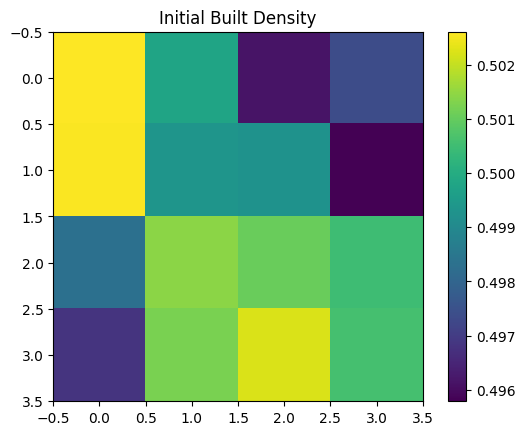

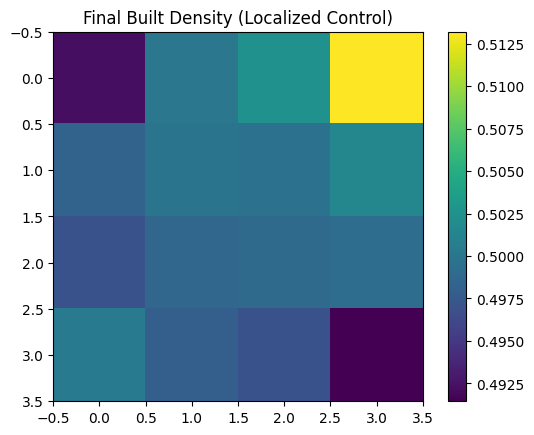

In [74]:
feature_index = 0

plot_feature(history_local[0], feature_index, "Initial Built Density")
plot_feature(history_local[-1], feature_index, "Final Built Density (Localized Control)")


## Experiment 1 - Global Control Scenario

Step 1: Define Control

In [75]:
d = feature_grid.shape[2]

u_global = np.zeros(d)
u_global[0] = 0.05   # Built density ↑
u_global[1] = -0.03  # Vegetation ↓

mask_global = np.ones((feature_grid.shape[0], feature_grid.shape[1]))

Step 2: Run Simulation

In [76]:
history_global = simulate_spatial_scenario(
    feature_grid,
    alpha=0.1,
    control_vector=u_global,
    mask=mask_global,
    steps=20
)

Step 3: Generate Time-Series  

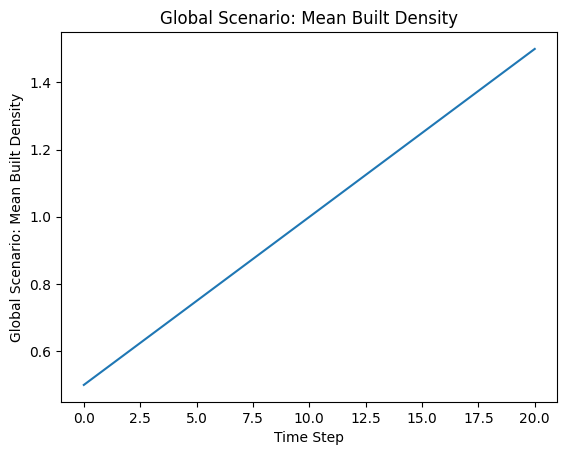

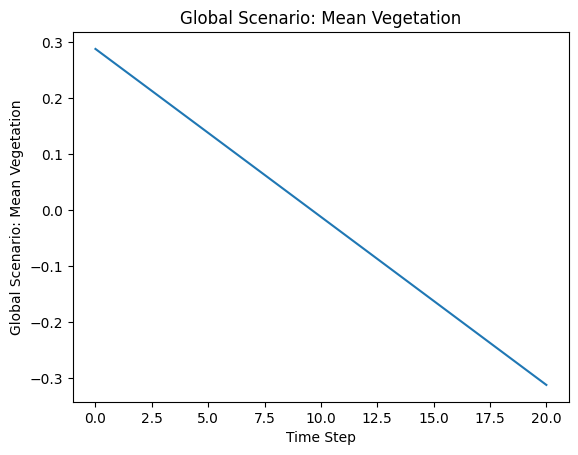

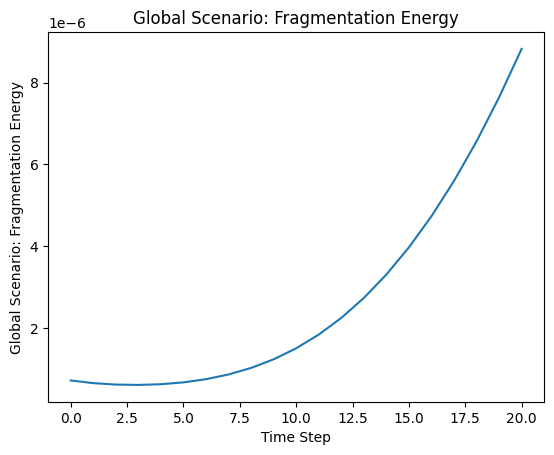

In [77]:
time_series_global = track_semantic_evolution(history_global)

for key in time_series_global:
    plot_indicator(time_series_global[key], f"Global Scenario: {key}")

Step 4: Generate Spatial Figures

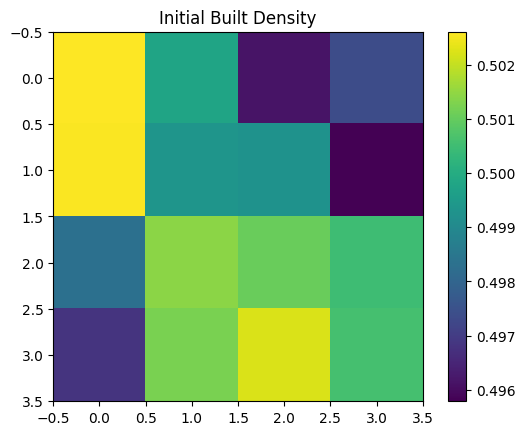

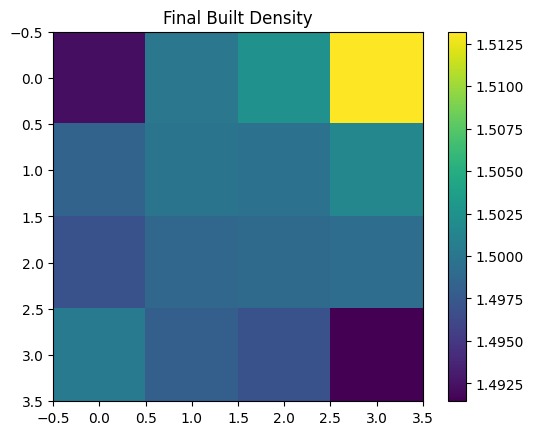

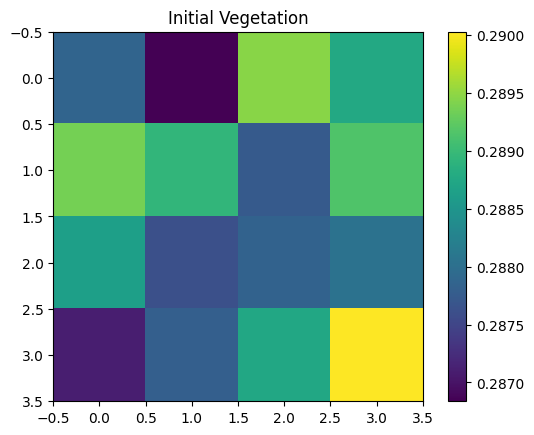

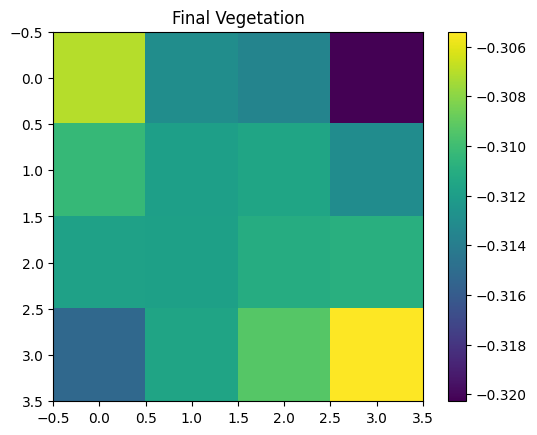

In [78]:
plot_feature(history_global[0], 0, "Initial Built Density")
plot_feature(history_global[-1], 0, "Final Built Density")

plot_feature(history_global[0], 1, "Initial Vegetation")
plot_feature(history_global[-1], 1, "Final Vegetation")

Step 5 - Stability Check

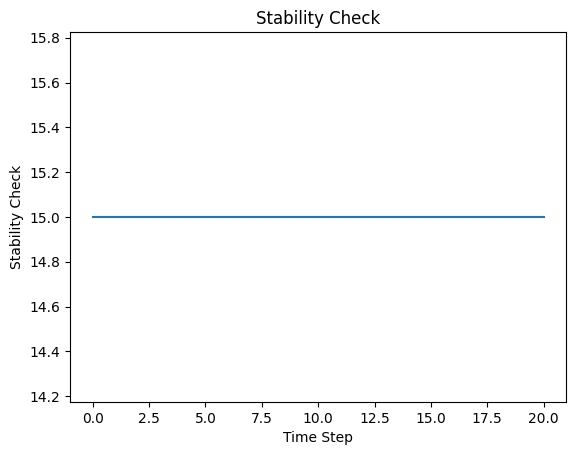

In [79]:
stability_global = check_stability(history_global)
plot_indicator(stability_global, "Stability Check")

In [80]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import PowerNorm

def plot_experiment1_spatial(history):

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))


    im1 = axes[0,0].imshow(
        history[0][:,:,0],
        cmap="viridis",
        interpolation="bicubic",
        norm=PowerNorm(gamma=0.7)
    )

    axes[0,0].set_title("Initial Built Density")

    fig.colorbar(
        im1,
        ax=axes[0,0],
        fraction=0.046,
        pad=0.04
    )

    im2 = axes[0,1].imshow(
        history[-1][:,:,0],
        cmap="viridis",
        interpolation="bicubic",
        norm=PowerNorm(gamma=0.7)
    )

    axes[0,1].set_title("Final Built Density")

    fig.colorbar(
        im2,
        ax=axes[0,1],
        fraction=0.046,
        pad=0.04
    )

    # ---------------- Vegetation ----------------
    vmin=np.percentile(history[-1][:,:,1], 5),
    vmax=np.percentile(history[-1][:,:,1], 95)

    im3 = axes[1,0].imshow(
        history[0][:,:,1],
        cmap="viridis",
        interpolation="bicubic",
        norm=PowerNorm(gamma=0.7)
    )

    axes[1,0].set_title("Initial Vegetation")

    fig.colorbar(
        im3,
        ax=axes[1,0],
        fraction=0.046,
        pad=0.04
    )

    im4 = axes[1,1].imshow(
        history[-1][:,:,1],
        cmap="viridis",
        interpolation="bicubic",
        norm=PowerNorm(gamma=0.7)
    )

    axes[1,1].set_title("Final Vegetation")

    fig.colorbar(
        im4,
        ax=axes[1,1],
        fraction=0.046,
        pad=0.04
    )

    for ax in axes.flatten():
        ax.axis("off")

    plt.tight_layout()
    plt.show()

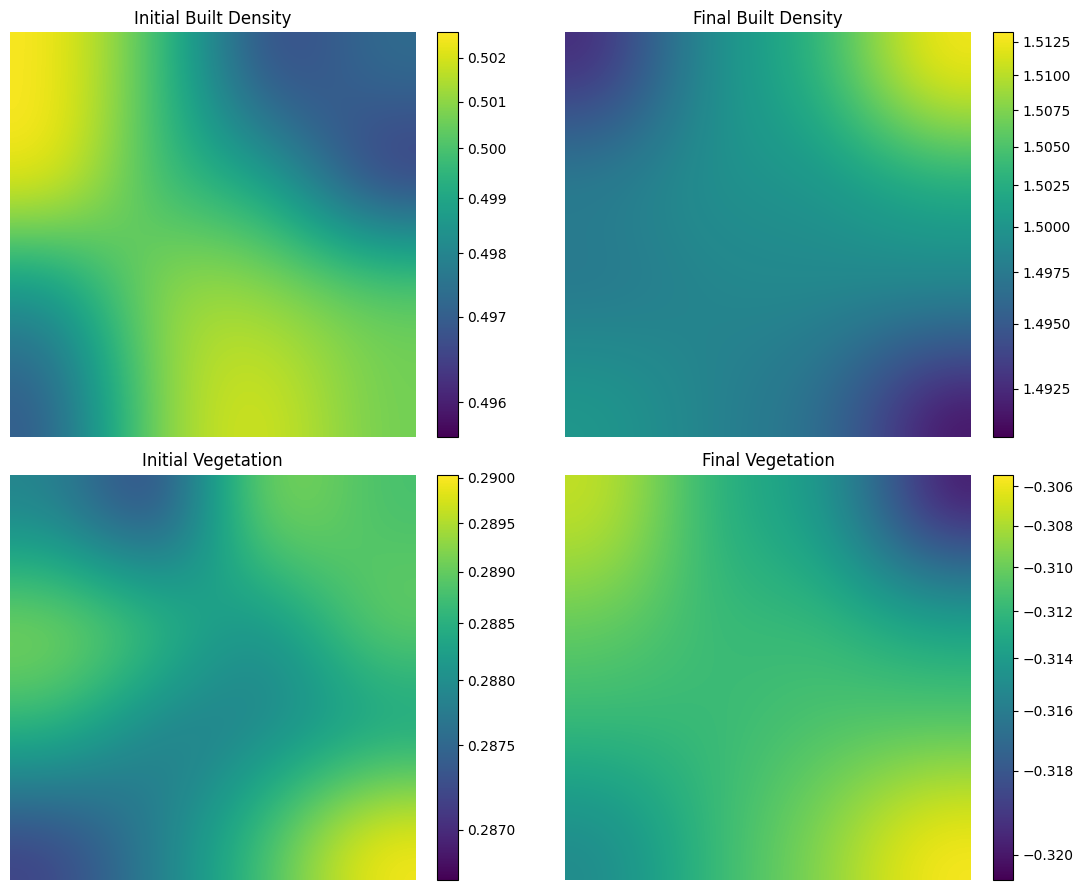

In [81]:
plot_experiment1_spatial(history_global)

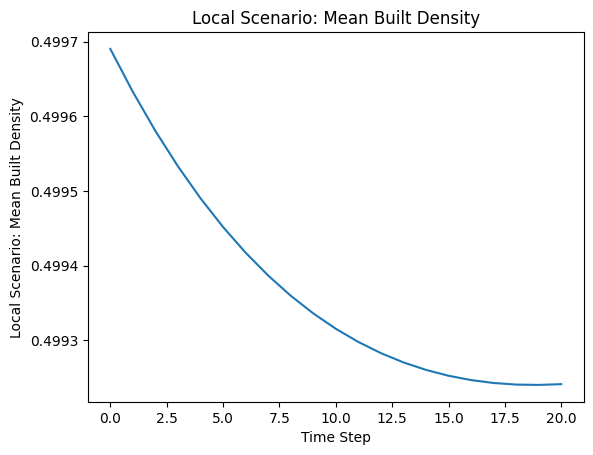

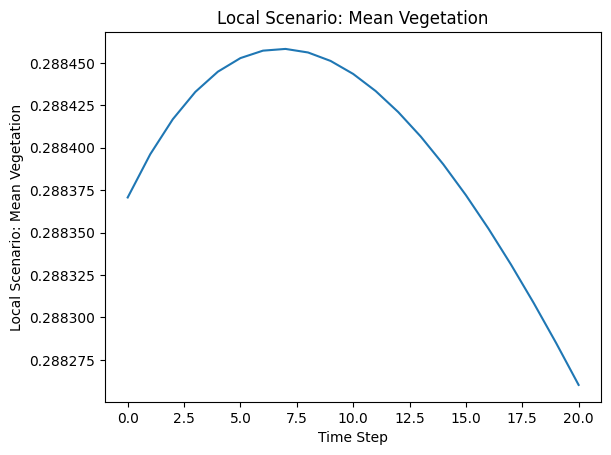

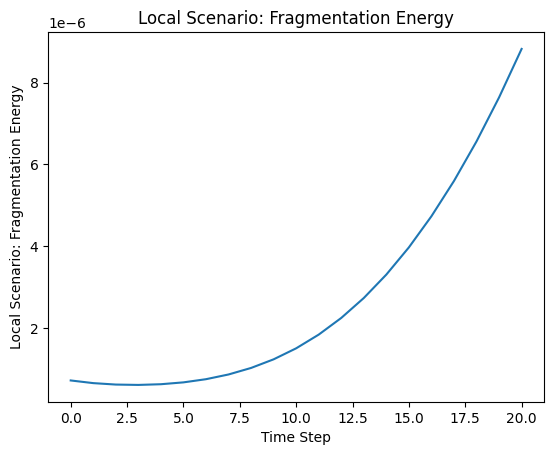

In [82]:
time_series_local = track_semantic_evolution(history_local)

for key in time_series_local:
    plot_indicator(time_series_local[key], f"Local Scenario: {key}")

In [83]:
import matplotlib.pyplot as plt
import numpy as np

def plot_experiment2_spatial(history):

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))

    # ---------- Built Density ----------
    vmin_b = min(history[0][:,:,0].min(), history[-1][:,:,0].min())
    vmax_b = max(history[0][:,:,0].max(), history[-1][:,:,0].max())

    im1 = axes[0,0].imshow(
        history[0][:,:,0],
        cmap="viridis",
        vmin=np.percentile(history[-1][:,:,0], 5),
        vmax=np.percentile(history[-1][:,:,0], 95),
        interpolation="bicubic"
    )
    axes[0,0].set_title("Initial Built Density (t=0)")
    fig.colorbar(im1, ax=axes[0,0], fraction=0.046, pad=0.04)

    im2 = axes[0,1].imshow(
        history[-1][:,:,0],
        cmap="viridis",
        vmin=vmin_b,
        vmax=vmax_b,
        interpolation="bicubic"
    )
    axes[0,1].set_title("Final Built Density (Localized Control)")
    fig.colorbar(im2, ax=axes[0,1], fraction=0.046, pad=0.04)

    # ---------- Vegetation ----------
    vmin_v = min(history[0][:,:,1].min(), history[-1][:,:,1].min())
    vmax_v = max(history[0][:,:,1].max(), history[-1][:,:,1].max())

    im3 = axes[1,0].imshow(
        history[0][:,:,1],
        cmap="viridis",
        vmin=vmin_v,
        vmax=vmax_v,
        interpolation="bicubic"
    )
    axes[1,0].set_title("Initial Vegetation (t=0)")
    fig.colorbar(im3, ax=axes[1,0], fraction=0.046, pad=0.04)

    im4 = axes[1,1].imshow(
        history[-1][:,:,1],
        cmap="viridis",
        vmin=vmin_v,
        vmax=vmax_v,
        interpolation="bicubic"
    )
    axes[1,1].set_title("Final Vegetation (Localized Control)")
    fig.colorbar(im4, ax=axes[1,1], fraction=0.046, pad=0.04)

    for ax in axes.flatten():
        ax.axis("off")

    plt.tight_layout()
    plt.show()

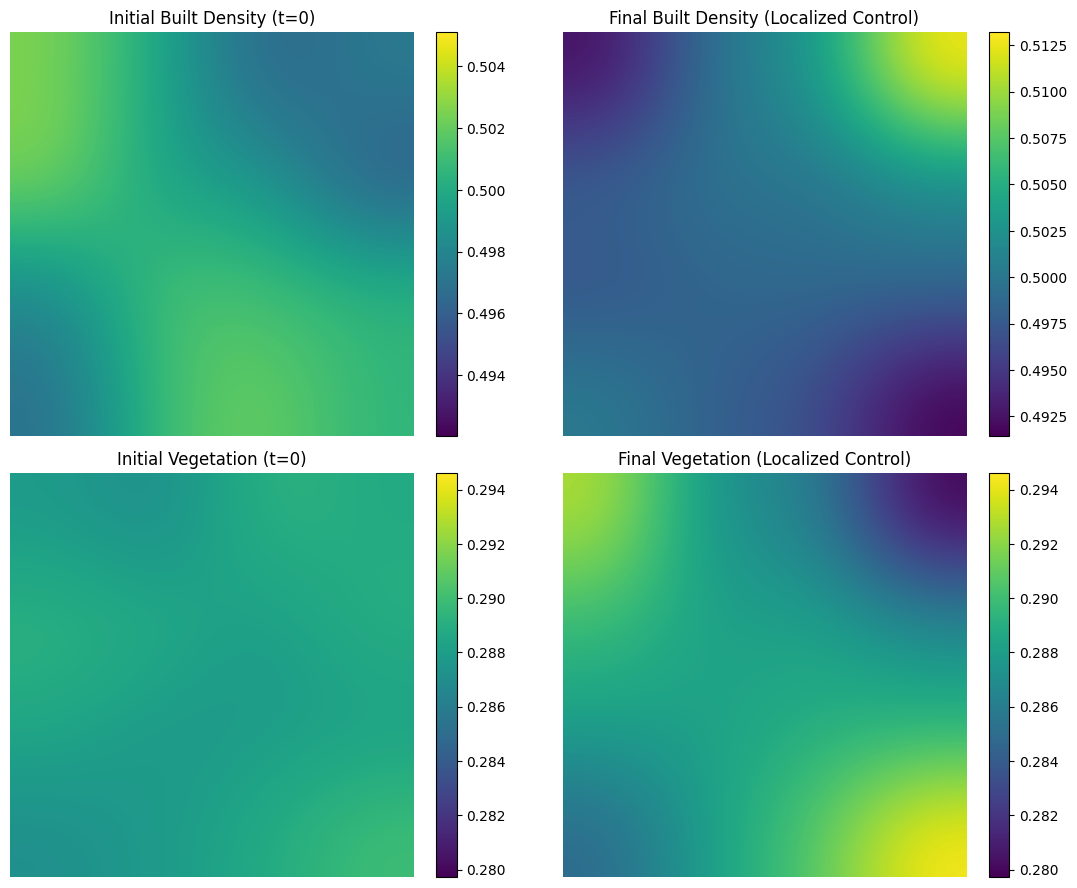

In [84]:
plot_experiment2_spatial(history_local)